5.	Implement a Global intensity thresholding algorithm on an image. Show the Fourier transform of the results. Show the histograms.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import math

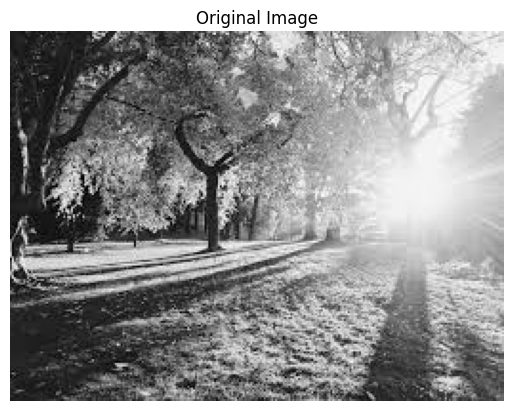

In [38]:
img=cv2.imread("E:\\BG\\sun.jpeg",0)
plt.imshow(img,cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

In [39]:
T=125
threshold_diff=0.1


In [40]:
rows,cols=img.shape
while True:
    less_pix=list()
    more_pix=list()
    for i in range(rows):
        for j in range(cols):
            if img[i][j]<T:
                less_pix.append(img[i][j])
            else:
                more_pix.append(img[i][j])
    m1=sum(less_pix)/len(less_pix)
    m2=sum(more_pix)/len(more_pix)
    T_new=(m1+m2)/2
    diff=abs(T_new - T)
    if diff<threshold_diff:
        break
    T=T_new

C:\Users\ASMIT HALDER\AppData\Local\Temp\ipykernel_16920\417640626.py:11: RuntimeWarning: overflow encountered in scalar add
  m1=sum(less_pix)/len(less_pix)
C:\Users\ASMIT HALDER\AppData\Local\Temp\ipykernel_16920\417640626.py:12: RuntimeWarning: overflow encountered in scalar add
  m2=sum(more_pix)/len(more_pix)


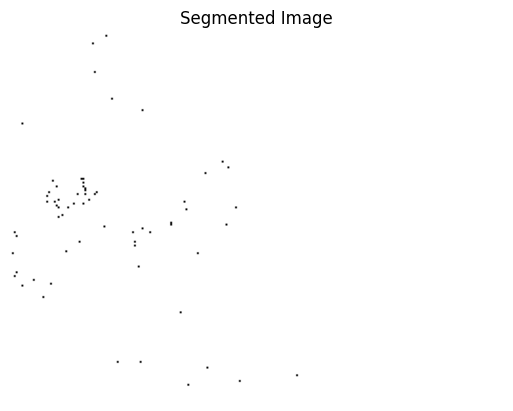

In [43]:
new_img=np.zeros(img.shape)
for i in range(rows):
    for j in range(cols):
        if img[i][j]<T:
            new_img[i][j]=0
        else:
            new_img[i][j]=255
plt.imshow(new_img,cmap='gray')
plt.title("Segmented Image")
plt.axis('off')
plt.show()

Fourier Transform

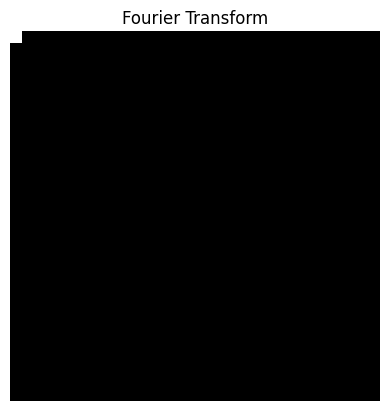

In [44]:
new_img=cv2.resize(new_img,(32,32))
rows1,cols1=new_img.shape
real=np.zeros(new_img.shape,dtype=np.uint32)
imag=np.zeros(new_img.shape,dtype=np.uint32)
magnitude=np.zeros(new_img.shape,dtype=np.uint32)
for u in range(rows1):
    for v in range(cols1):
        sum_real=0
        sum_imag=0
        for x in range(rows1):
            for y in range(cols1):
                angle=2*math.pi*(u*x/rows1 + v*y/cols1)
                pixel=new_img[x][y]
                sum_real+=pixel*math.cos(angle)
                sum_imag+=pixel*math.sin(angle)
        real[u][v]=sum_real
        imag[u][v]=sum_imag
        magnitude[u][v]=math.sqrt(sum_real**2 + sum_imag**2)
plt.imshow(magnitude,cmap='gray')
plt.title("Fourier Transform")
plt.axis('off')
plt.show()
        


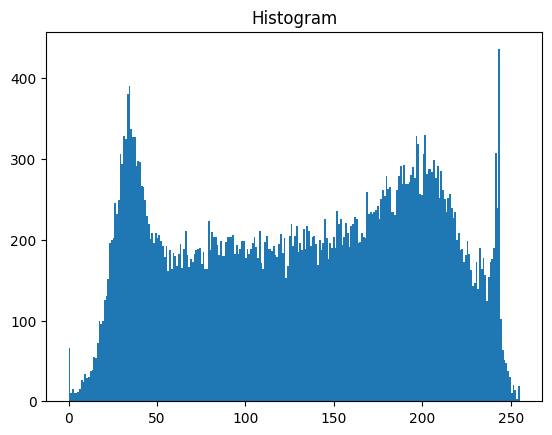

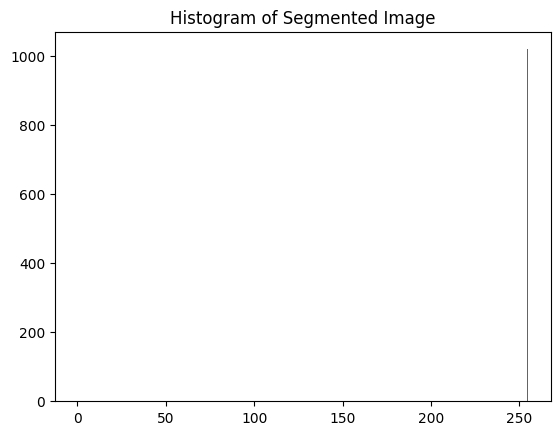

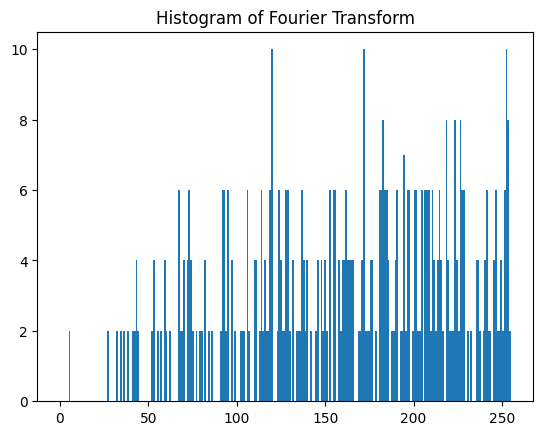

In [49]:
hist=[]
for i in range(rows):
    for j in range(cols):
        hist.append(img[i][j])
plt.hist(hist,bins=256,range=(0,255))
plt.title("Histogram")
plt.show()

hist1=[]
for i in range(rows1):
    for j in range(cols1):
        hist1.append(new_img[i][j])
plt.hist(hist1,bins=256,range=(0,255))
plt.title("Histogram of Segmented Image")
plt.show()

hist2=[]
for i in range(rows1):
    for j in range(cols1):
        hist2.append(magnitude[i][j])
plt.hist(hist2,bins=256,range=(0,255))
plt.title("Histogram of Fourier Transform")
plt.show()